In [1]:
import numpy as np
from matplotlib import pyplot as plt
#%matplotlib inline
#%config InlineBackend.figure_format='retina'
import scipy.stats
from scipy.stats import norm

You can find the lecture [here](https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/lectures/L05_frequentist.ipynb)

We generate $N$ Gaussian variables with $\mu=1$ in a.u. and $\sigma$ drawn from another Gaussian pdf with $\mu_\sigma=0.2$ and $\sigma_\sigma=0.05$, so as to implement the more generale case of heteroscedastic errors.

# Part I

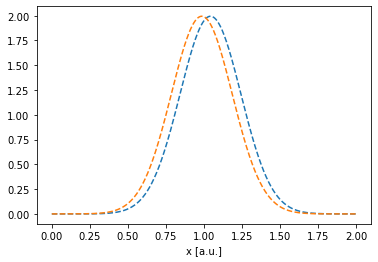

In [2]:
"""
generate N Gaussian variables
"""
mu_0=1
mu_sigma=0.2
sigma_sigma=0.05
N=2
#-----------------
"""
generate uncertainties
"""
#sigma=np.random.normal(mu_sigma,sigma_sigma,N) #for heteroscedastic errors
sigma=np.repeat(mu_sigma,N) #for homoscedastic errors
#-----------------
"""
generate measurements
"""
xi=np.concatenate([np.random.normal(mu_0,s) for s in zip(sigma)])
#-----------------
"""
plot the N likelihoods
"""
xgrid = np.linspace(0,2,1000)
y = np.array([norm.pdf(xgrid,loc=x_0,scale=s) for (x_0,s) in zip(xi,sigma)])
#-----------------
fig, ax = plt.subplots()
#figsize=(5, 5)
for yi in y:
    plt.plot(xgrid,yi,ls='--')
plt.xlabel('x [a.u.]')
plt.show()

We compute the likelihood letting the parameter $\mu$ take discrete values along the $\mu$-axis and assuming the $N$ uncertainties $\sigma_i$ to be known and homogeneous (homoscedasticity):

$$\hat{\mu} \equiv \max_{\mu} L(\mu) = \max_\mu\Big(\prod_i^N p(x_i|\mu)\Big)$$

We define a ($N,M$)-array: $N$ likelihoods for each of the $M$ values we let $\mu$ vary over

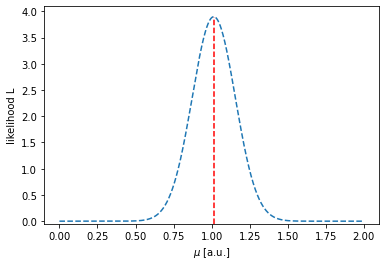

L(μ) attains maximum at μ = 1.02


In [3]:
mu_grid = np.linspace(0,2,1000) #points on the μ parameter space
p_i=[norm.pdf(xi, loc=mu_var, scale=sigma) for mu_var in mu_grid] #array containing the single likelihoods to be multiplied, starting at μ=0
L=np.prod(p_i,axis=1)#likelihood; multiply each of the N likelihoods at fixed μ

#-----------------

vertical_axis_min = -0.05 #bottom edge of the canvas
fig, ax = plt.subplots()
plt.plot(xgrid,L,ls='--') #likelihood L(μ) plot

estimate_mu = xgrid[np.argsort(L)[len(L)-1]]
x_vertical_line = np.repeat(estimate_mu,1000) #x coordinates of the points used to create the vertical line
y_vertical_line = np.linspace(vertical_axis_min,np.max(L),1000) #y coordinates of the points used to create the vertical line

plt.plot(x_vertical_line,y_vertical_line,ls='--',color='red') #vertical-line plot
plt.xlabel('$\mu$ [a.u.]')
plt.ylabel('likelihood L')
plt.ylim(ymin=vertical_axis_min)
plt.show()

#-----------------

print(f'L(μ) attains maximum at μ = {estimate_mu:.2f}')

# Part II : error estimate

Calculation of Fisher-element and error $\sigma_{\hat{\mu}}$, defined as

$$\sigma_{\hat{\mu}} \equiv \Bigg(-\frac{d^2 L}{d\mu^2}\Bigg)^{-1/2} \Big|_{\mu=\hat{\mu}}$$

In [4]:
#numerical second-order differentiation
delta_squared_L = np.diff(L,n=2) #2-order derivative of L 
delta_mu_squared = np.diff(mu_grid**2,n=2) #derivative of μ^2
F_squared = -1*np.divide(delta_squared_L,delta_mu_squared) #element of Fisher matrix

#-----------------

mask = F_squared>0 #select dμ where L(μ) has negative convexity
second_derivative = np.power(F_squared[mask],0.5) #values of dL^2/dμ^2 for allowed μ_i 
error = 1/np.max(second_derivative) #identify error with the maximum value for convexity

Plot featuring confidence level

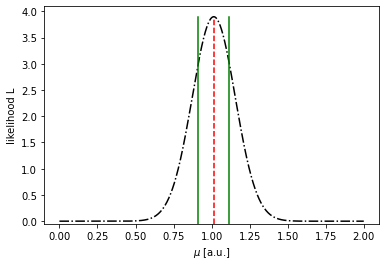

Confidence level: (0.914,1.116)


In [5]:
vertical_axis_min = -0.05 #bottom edge of the canvas
fig, ax = plt.subplots()
plt.plot(xgrid,L,ls='dashdot',color='black') #likelihood L(μ) plot

#-----------------

#error on estimate vertical bars
x_right_vertical_line = np.repeat(estimate_mu+error,1000)
x_left_vertical_line = np.repeat(estimate_mu-error,1000)

plt.plot(x_vertical_line,y_vertical_line,ls='--',color='red') #vertical-line plot
plt.plot(x_right_vertical_line,y_vertical_line,ls='-',color='green') #vertical-line plot
plt.plot(x_left_vertical_line,y_vertical_line,ls='-',color='green') #vertical-line plot

plt.xlabel('$\mu$ [a.u.]')
plt.ylabel('likelihood L')
plt.ylim(ymin=vertical_axis_min)
plt.show()

print(f'Confidence level: ({estimate_mu-error:.3f},{estimate_mu+error:.3f})')